<a href="https://colab.research.google.com/github/AmaraRao19/HeartDiseasePrediction/blob/main/HeartDisease_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------    

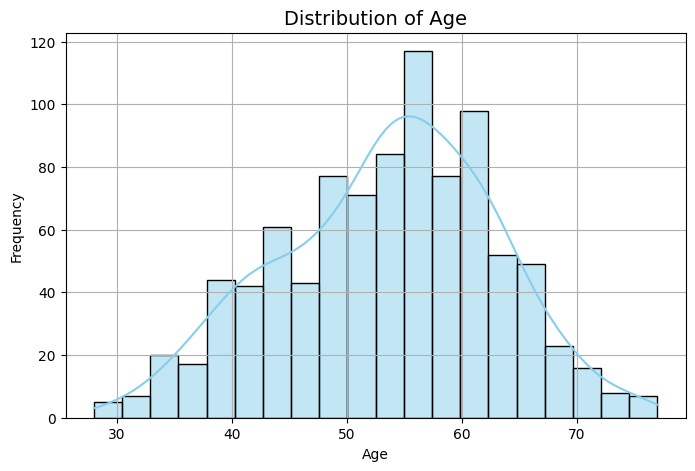

/tmp/ipykernel_239/1469840070.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette="Set2")


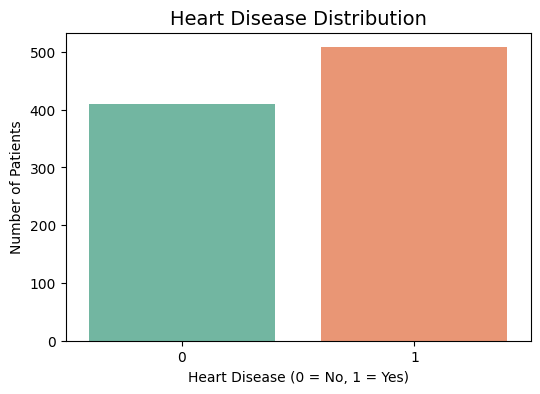

/tmp/ipykernel_239/1469840070.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='Age', data=df, palette="coolwarm")


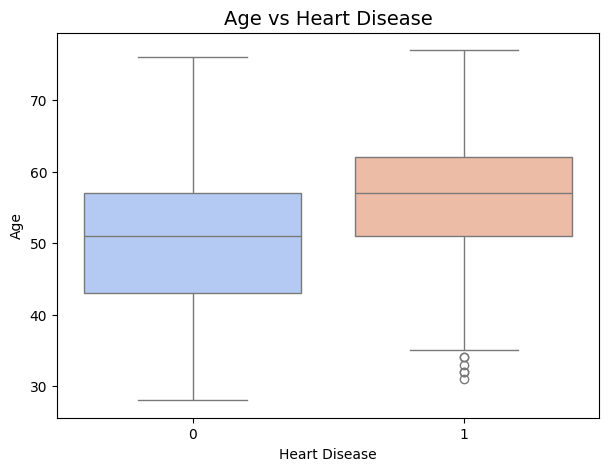

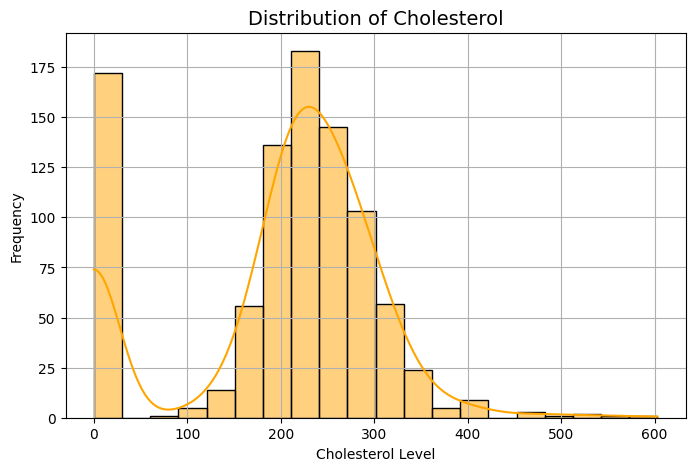

/tmp/ipykernel_239/1469840070.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='MaxHR', data=df, palette="viridis")


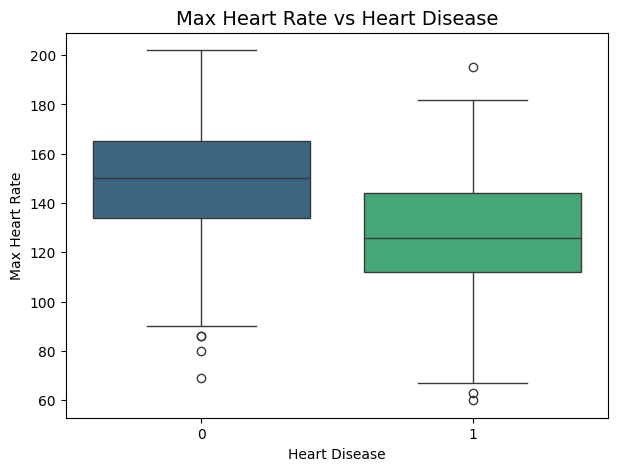

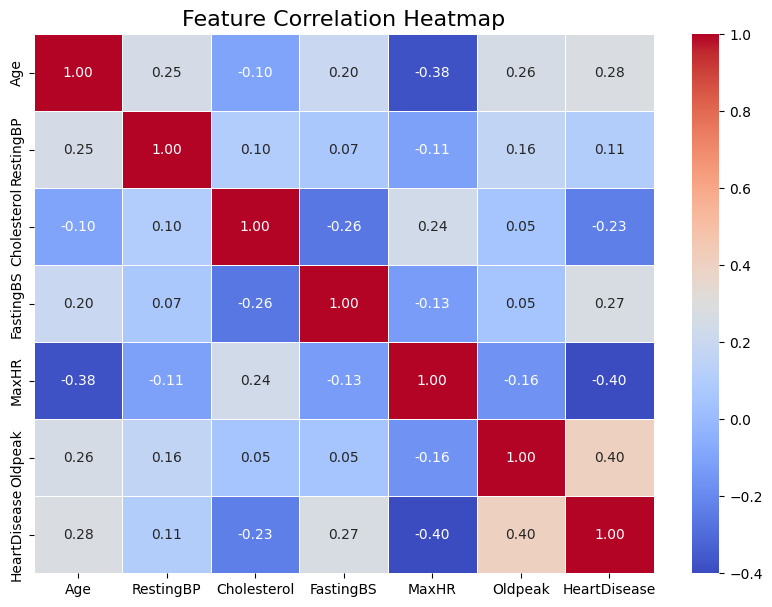

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#EDA STEPS:
# 1️. Load Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/heartFailure/heart.csv")

print("Dataset Preview:\n")
print(df.head())

print("\n\nDataset Information:\n")
df.info()

print("\n\nStatistical Summary:\n")
print(df.describe())


# 2️. Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')

plt.title("Distribution of Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()


# 3️. Heart Disease Count
plt.figure(figsize=(6,4))

sns.countplot(x='HeartDisease', data=df, palette="Set2")

plt.title("Heart Disease Distribution", fontsize=14)
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()


# 4️. Age vs Heart Disease
plt.figure(figsize=(7,5))

sns.boxplot(x='HeartDisease', y='Age', data=df, palette="coolwarm")

plt.title("Age vs Heart Disease", fontsize=14)
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()


# 5️. Cholesterol Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Cholesterol'], bins=20, kde=True, color='orange')

plt.title("Distribution of Cholesterol", fontsize=14)
plt.xlabel("Cholesterol Level")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()


# 6️. Max Heart Rate vs Disease
plt.figure(figsize=(7,5))

sns.boxplot(x='HeartDisease', y='MaxHR', data=df, palette="viridis")

plt.title("Max Heart Rate vs Heart Disease", fontsize=14)
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate")

plt.show()


# 7️. Correlation Heatmap
plt.figure(figsize=(10,7))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap", fontsize=16)

plt.show()

#DATA PRE-PROCESSING:

Handling Missing values

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Detecting outliers

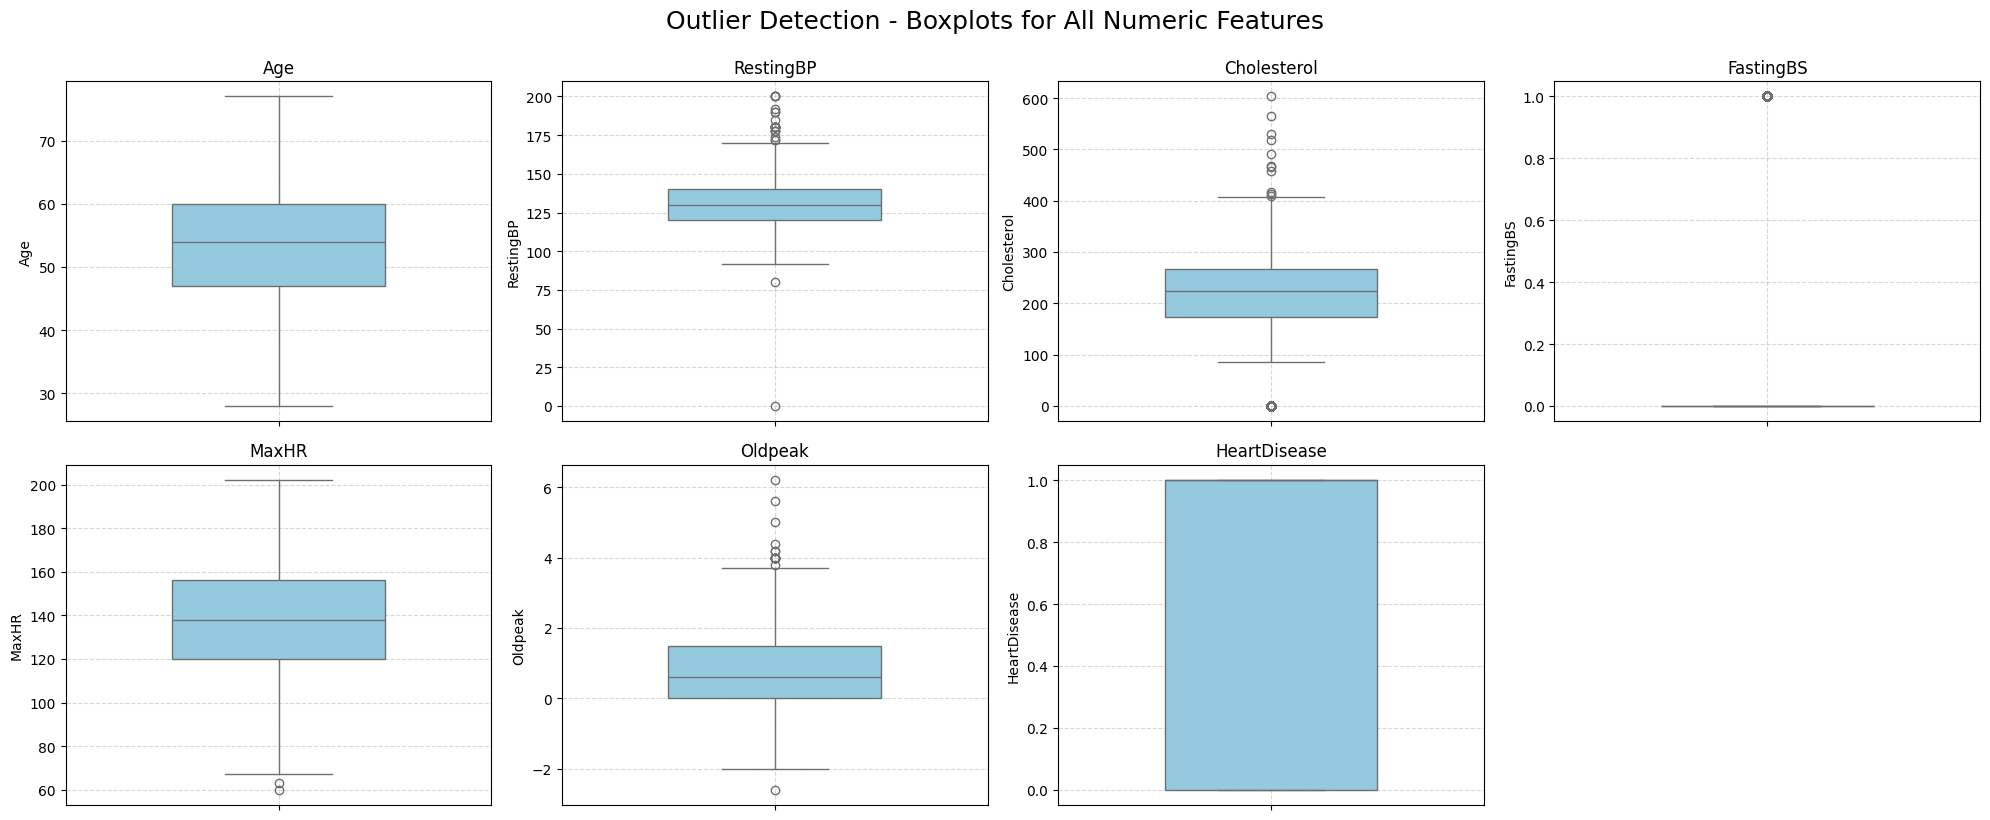

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric features
df_numeric = df.select_dtypes(include=np.number)

# Count number of features
num_features = df_numeric.shape[1]

# Set layout (adjust columns for best visual layout)
n_cols = 4
n_rows = int(np.ceil(num_features / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle("Outlier Detection - Boxplots for All Numeric Features", fontsize=18, y=1.02)

# Loop over each feature and plot boxplot
for i, col in enumerate(df_numeric.columns):
    row = i // n_cols
    col_idx = i % n_cols
    sns.boxplot(y=df_numeric[col], ax=axes[row, col_idx], color='skyblue', width=0.5)
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

removing outliers

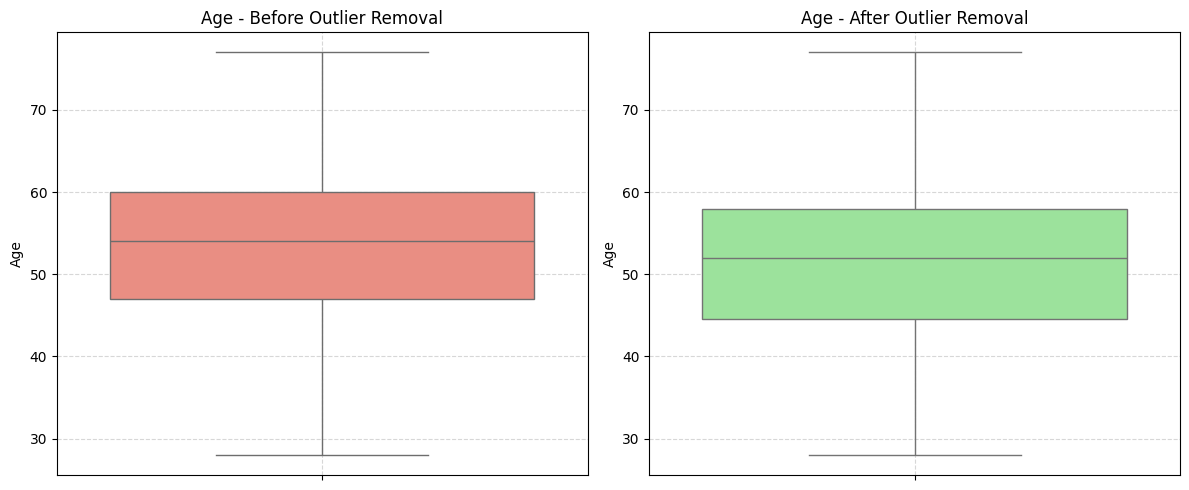

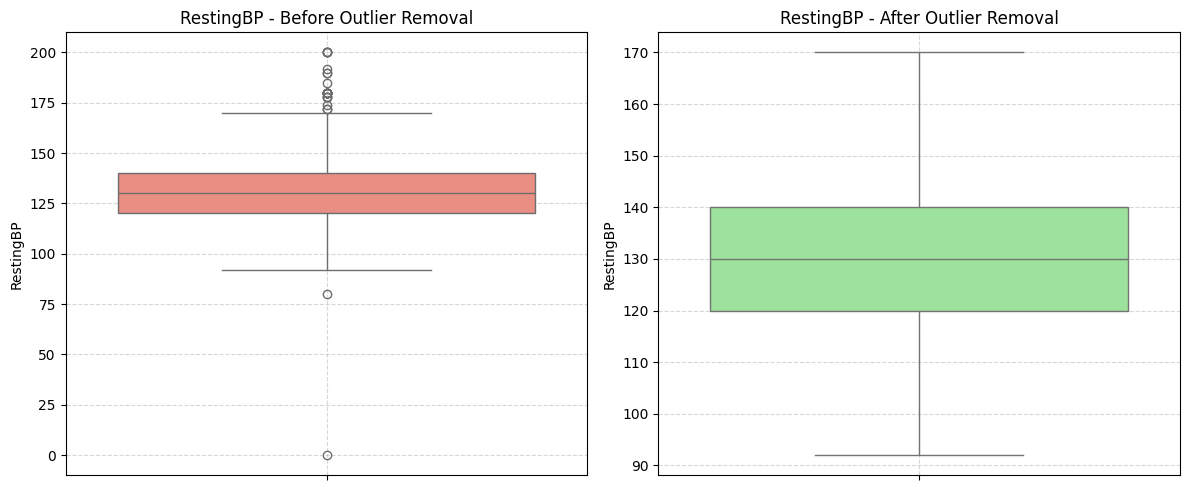

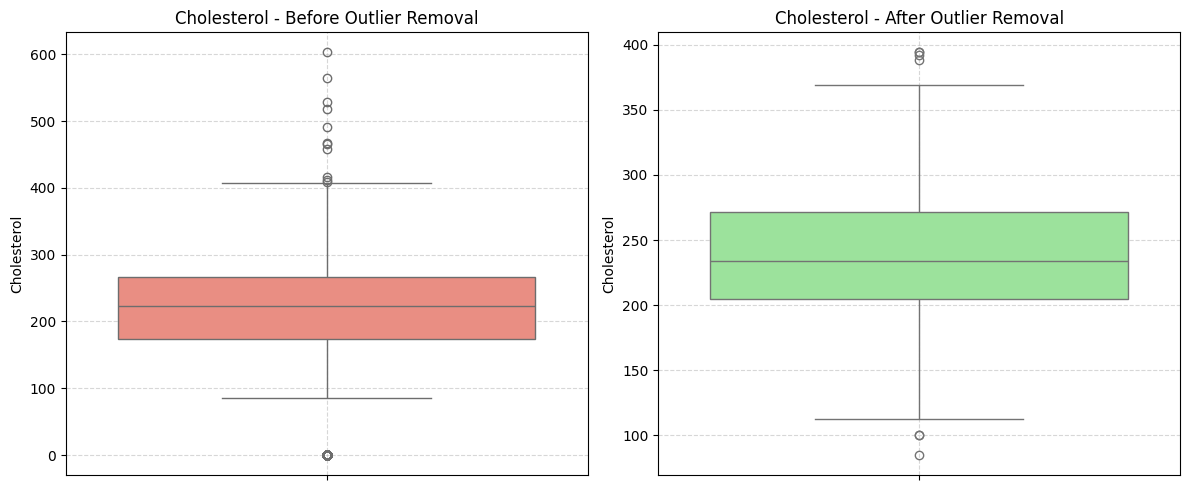

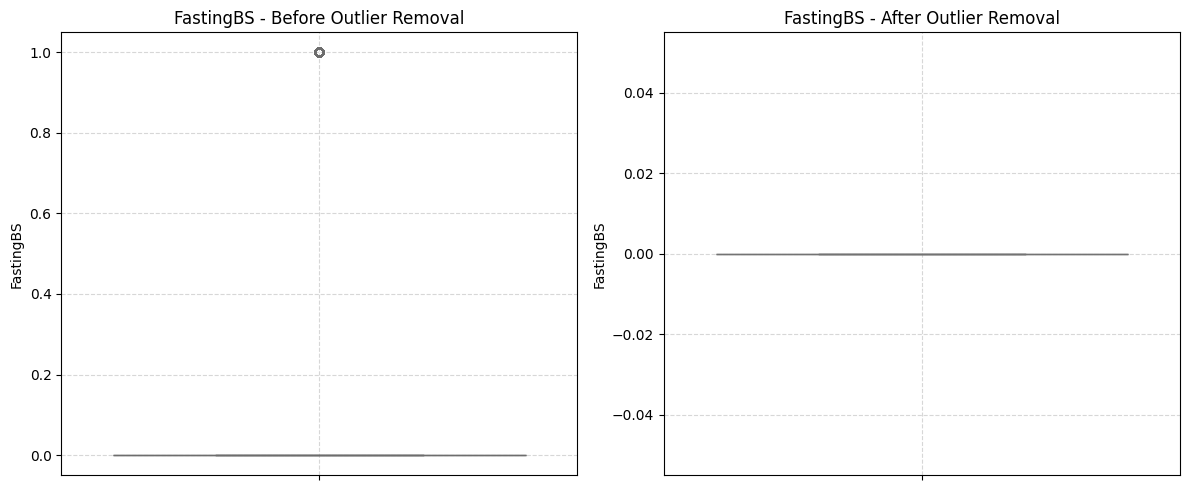

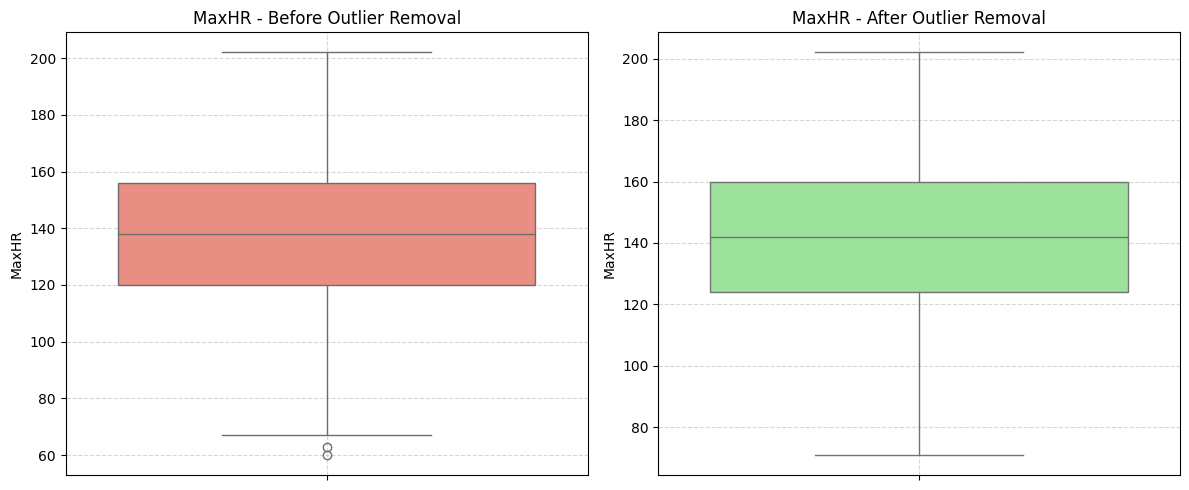

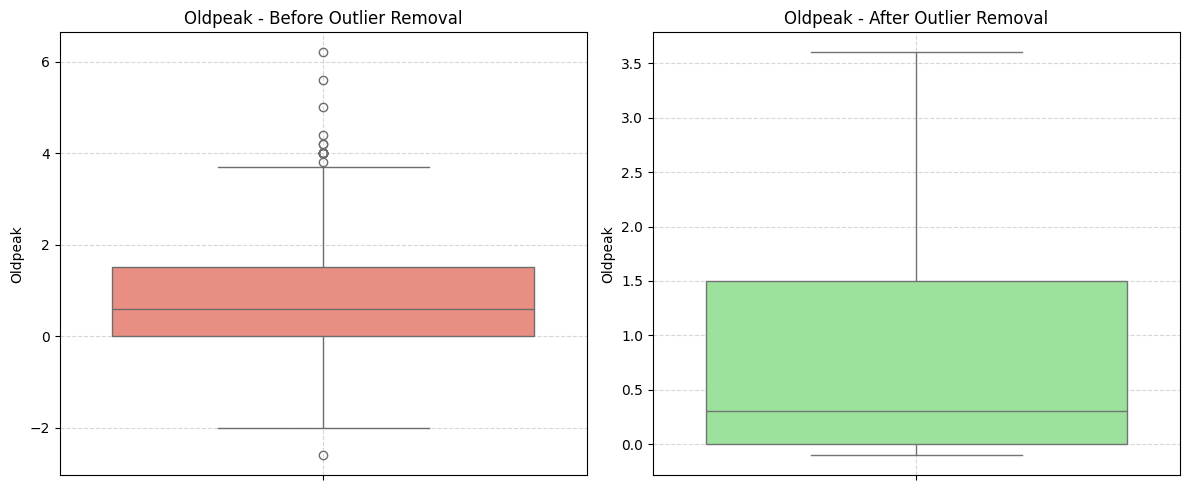

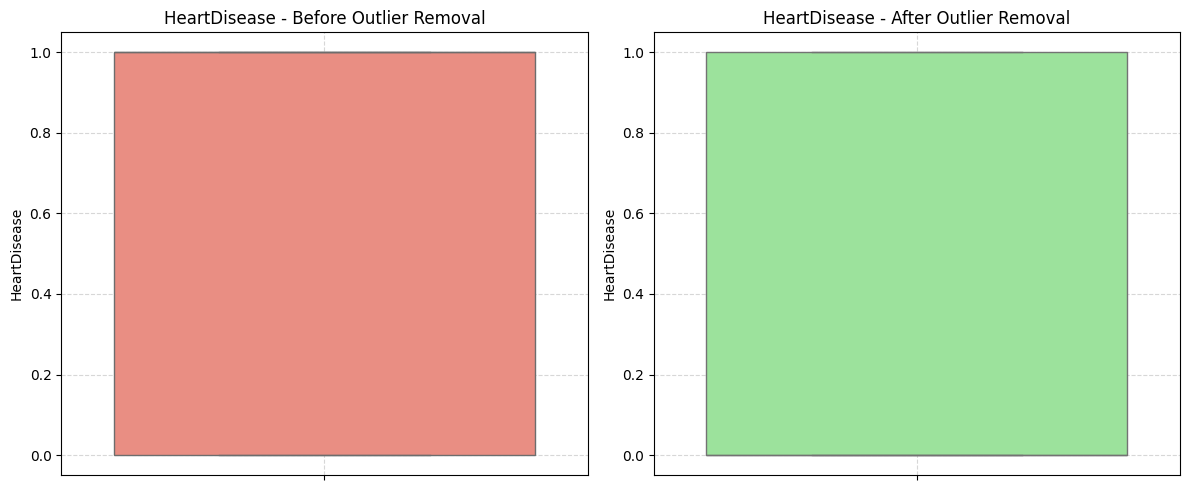

Original shape: (918, 12)
After outlier removal: (587, 12)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a copy of the original data
df_original = df.copy()
df_cleaned = df.copy()

# Get numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Remove outliers using IQR for each numeric column
for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

# Show before and after boxplots
for col in numeric_cols:
    plt.figure(figsize=(12, 5))

    # Before removal
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_original[col], color="salmon")
    plt.title(f"{col} - Before Outlier Removal")
    plt.grid(True, linestyle='--', alpha=0.5)

    # After removal
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_cleaned[col], color="lightgreen")
    plt.title(f"{col} - After Outlier Removal")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Print shape comparison
print(f"Original shape: {df_original.shape}")
print(f"After outlier removal: {df_cleaned.shape}")

 Encoding Categorical Variables

In [ ]:
# Check data types
print(df.dtypes)

# Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Print complete encoded dataset
print("Encoded Data:\n", df_encoded)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object
Encoded Data:
      Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140          289          0    172      0.0             0   
1     49        160          180          0    156      1.0             1   
2     37        130          283          0     98      0.0             0   
3     48        138          214          0    108      1.5             1   
4     54        150          195          0    122      0.0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45        110          264          0    132      1.2             1   
914   68        144          193          1

Feature Scaling

In [ ]:
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Target column
target_col = "HeartDisease"

# Separate features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# One-Hot Encode categorical columns (all object dtype columns)
categorical_cols = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Now scale the numeric features (including the encoded dummies)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Feature Matrix After Encoding and Scaling:\n", X_scaled_df.head())

Feature Matrix After Encoding and Scaling:
         Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak     Sex_M  \
0 -1.433140   0.410909     0.825070  -0.551341  1.382928 -0.832432  0.515952   
1 -0.478484   1.491752    -0.171961  -0.551341  0.754157  0.105664 -1.938163   
2 -1.751359  -0.129513     0.770188  -0.551341 -1.525138 -0.832432  0.515952   
3 -0.584556   0.302825     0.139040  -0.551341 -1.132156  0.574711 -1.938163   
4  0.051881   0.951331    -0.034755  -0.551341 -0.581981 -0.832432  0.515952   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0           2.075177          -0.532838         -0.229679           0.814275   
1          -0.481887           1.876744         -0.229679           0.814275   
2           2.075177          -0.532838         -0.229679          -1.228087   
3          -0.481887          -0.532838         -0.229679           0.814275   
4          -0.481887           1.876744         -0.229679           0.81427

 Drop Irrelevant Features (if any)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_encoded, y)
mi_series = pd.Series(mi_scores, index=X_encoded.columns)

# Let's say low_importance features are those with MI < 0.01
low_importance_features = mi_series[mi_series < 0.01].index.tolist()

print("Dropping features with low importance:", low_importance_features)

# Drop these features from the scaled dataframe
X_selected = X_scaled_df.drop(columns=low_importance_features)

print("Shape after dropping irrelevant features:", X_selected.shape)

Dropping features with low importance: ['RestingBP', 'ChestPainType_TA', 'RestingECG_ST']
Shape after dropping irrelevant features: (918, 12)


#Train-Test Split

In [ ]:
# Separate features and target first
target_col = "HeartDisease"
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical features in X only (e.g., with pd.get_dummies)
X_encoded = pd.get_dummies(X, drop_first=True)

# Now X_encoded has encoded features; y remains unchanged
print(X_encoded.columns)

# Split train-test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')
Train set size: (642, 15)
Test set size: (276, 15)


#Classification Model (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)  # Increase iterations to avoid convergence warning
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

Prediction:

[1 1 1 0 0 1 1 1 0 0]
     Actual  Predicted
351       1          1
596       1          1
491       1          1
794       0          0
544       0          0
651       1          1
132       1          1
117       1          1
751       0          0
627       0          0
Model Accuracy: 0.8840579710144928
Confusion Matrix:
[[104  19]
 [ 13 140]]


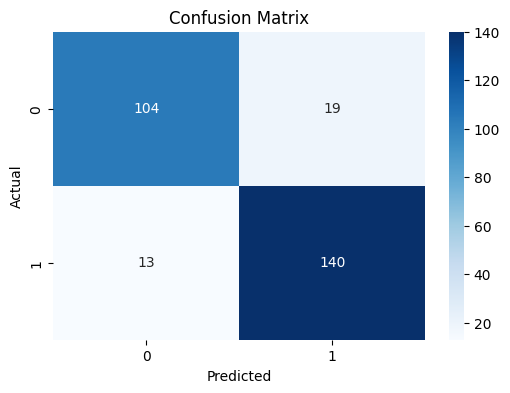

In [ ]:
y_pred = model.predict(X_test)
print(y_pred[:10])

#compare:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))

#calculate Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

#visualize Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC: model disease aur healthy patients ko kitna clearly separate kar pa raha hai.//
ROC-AUC Score:measures how well a classification model distinguishes between positive and negative classes.

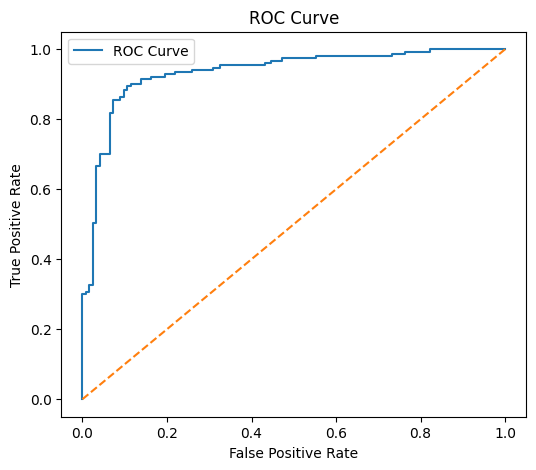

ROC-AUC Score: 0.9345342473032573


In [ ]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()



from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

#Highlight important features affecting prediction:

Feature Importance:

ChestPainType_NAP   -1.714698
ST_Slope_Up         -1.474463
ChestPainType_ATA   -1.393995
ChestPainType_TA    -1.382290
RestingECG_ST       -0.410081
RestingECG_Normal   -0.402378
MaxHR               -0.009979
Cholesterol         -0.004395
RestingBP           -0.000932
Age                  0.005244
Oldpeak              0.245933
ST_Slope_Flat        0.756968
ExerciseAngina_Y     0.872978
Sex_M                0.997142
FastingBS            1.072381
dtype: float64


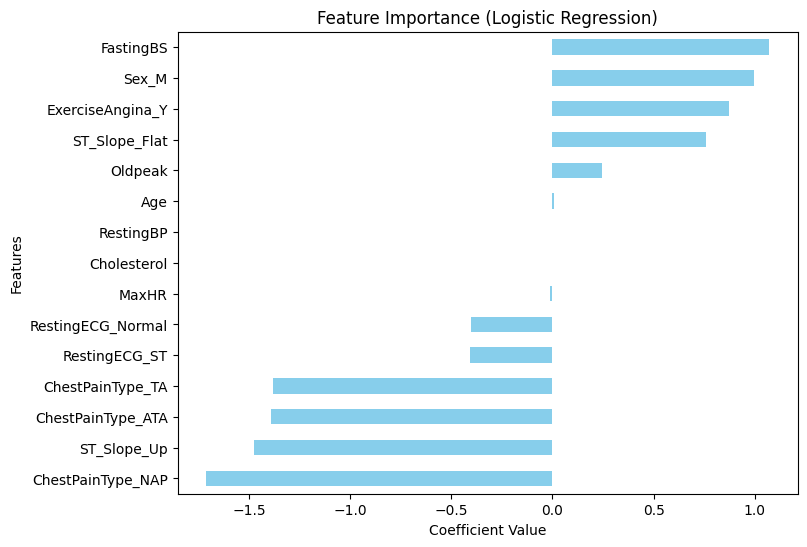

In [ ]:
# Logistic Regression coefficients se feature importance nikalna
import pandas as pd
import matplotlib.pyplot as plt

importance = model.coef_[0]

feature_importance = pd.Series(importance, index=X_scaled_df.columns)

feature_importance = feature_importance.sort_values()

# Print feature importance
print("Feature Importance:\n")
print(feature_importance)

# Bar plot
plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()